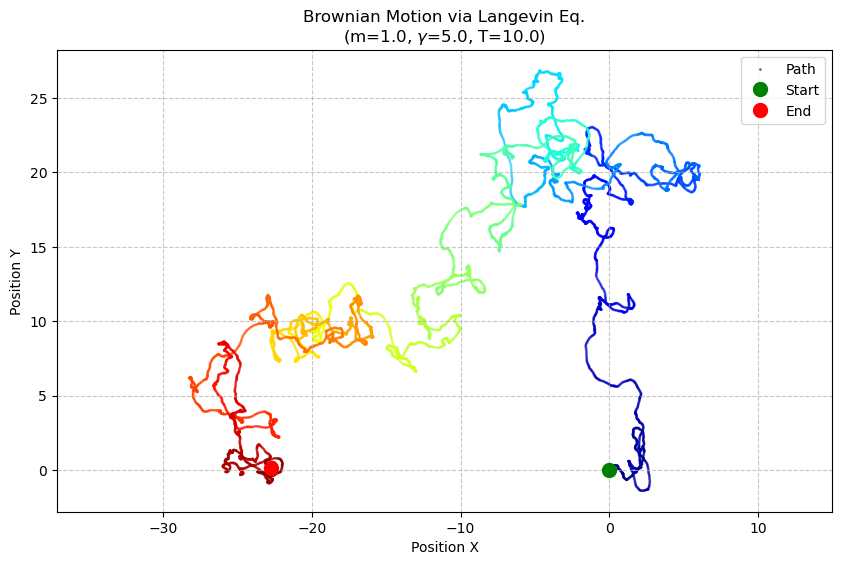

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_langevin_2d(n_steps, dt, m, gamma, T, k_B=1.0):
    """
    2次元ランジュバン方程式をオイラー・丸山法で解く関数
    
    Parameters:
      n_steps : ステップ数
      dt      : 時間刻み幅
      m       : 粒子の質量
      gamma   : 摩擦係数
      T       : 温度
      k_B     : ボルツマン定数（デフォルトは1として簡略化）
    """
    
    # ノイズの強度（揺動散逸定理: sigma = sqrt(2 * gamma * k_B * T)）
    sigma = np.sqrt(2 * gamma * k_B * T)
    
    # 位置(x, y)と速度(vx, vy)の配列を初期化
    r = np.zeros((n_steps, 2)) # 位置
    v = np.zeros((n_steps, 2)) # 速度
    
    # 時間発展（オイラー・丸山法）
    # dv = (-gamma/m * v) * dt + (sigma/m) * dW
    # dW はウィーナー過程の増分で、sqrt(dt) * N(0,1) に従う
    
    for i in range(n_steps - 1):
        # 現在の速度と位置
        v_curr = v[i]
        r_curr = r[i]
        
        # ガウスノイズの生成 (平均0, 分散1)
        noise = np.random.normal(0, 1, size=2)
        
        # 速度の更新
        # 決定論的な項: -(gamma/m)*v*dt
        # 確率的な項: (sigma/m) * sqrt(dt) * noise
        dv = -(gamma / m) * v_curr * dt + (sigma / m) * np.sqrt(dt) * noise
        v_next = v_curr + dv
        
        # 位置の更新
        dr = v_curr * dt
        r_next = r_curr + dr
        
        # 配列に格納
        v[i+1] = v_next
        r[i+1] = r_next
        
    return r, v

# --- パラメータ設定 ---
steps = 10000   # 計算ステップ数
dt = 0.01       # 時間刻み
mass = 1.0      # 質量
fric = 5.0      # 摩擦係数 (大きいと動きが鈍くなる)
temp = 10.0     # 温度 (大きいと激しく動く)

# --- シミュレーション実行 ---
trajectory, velocity = solve_langevin_2d(steps, dt, mass, fric, temp)

# --- プロット作成 ---
plt.figure(figsize=(10, 6))

# 軌跡のプロット
# 時間経過を色で表現（青→赤）
time_colors = np.linspace(0, 1, steps)
plt.scatter(trajectory[:, 0], trajectory[:, 1], c=time_colors, cmap='jet', s=1, alpha=0.5, label='Path')

# 開始点と終了点を強調
plt.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=10, label='Start')
plt.plot(trajectory[-1, 0], trajectory[-1, 1], 'ro', markersize=10, label='End')

plt.title(f"Brownian Motion via Langevin Eq.\n(m={mass}, $\gamma$={fric}, T={temp})")
plt.xlabel("Position X")
plt.ylabel("Position Y")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axis('equal') # 縦横比を揃える

plt.show()